In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
#import plotly.express as px 
import seaborn as sns

In [ ]:
dsf_data = pd.read_csv("data/2025-08-15_FlA_ZP_CKW_20250815_145006_AnalysisResults_wellresults_edited.txt", sep="\t")

pd.set_option('display.max_columns', None)

,#,Well,Buffer,Salt,Ligand,Protein,Task,Tm B,dTm B,B Fit,Tm B Start,Tm B End,Flag Indicator,Single/Multiple,Analysis Mode,Tm D,dTm D,High Background,High NPC,Algorithm Failure,Sparse Data,Low Signal,Poor Fit,Replicate Mismatch,Multiple Melts,Reference Mismatch,Analysis Group,Experiment File Name
0,1,A01,NaN,NaN,C2,FlA_WT,Sample,56.387486,NaN,1.206362,47.060500,63.781456,0,Single,Manual,56.858227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AG 1,2025-08-15_FlA_ZP_CKW.eds
1,2,A02,NaN,NaN,C2,FlA_WT,Sample,56.914474,NaN,1.028338,47.060500,63.781456,0,Single,Manual,57.303240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AG 1,2025-08-15_FlA_ZP_CKW.eds
2,3,A03,NaN,NaN,C2,FlA_WT,Sample,56.752610,NaN,1.060860,47.060500,63.781456,0,Single,Manual,57.153755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AG 1,2025-08-15_FlA_ZP_CKW.eds
3,4,A04,NaN,NaN,rxn,FlA_WT,Sample,56.693210,NaN,1.023652,49.089146,62.551970,0,Single,Manual,56.856976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AG 1,2025-08-15_FlA_ZP_CKW.eds
4,5,A05,NaN,NaN,rxn,FlA_WT,Sample,56.846786,NaN,1.053925,48.597355,61.261017,0,Single,Manual,57.406975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AG 1,2025-08-15_FlA_ZP_CKW.eds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92,H08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Single,Auto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-15_FlA_ZP_CKW.eds
92,93,H09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Single,Auto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-15_FlA_ZP_CKW.eds
93,94,H10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Single,Auto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-15_FlA_ZP_CKW.eds
94,95,H11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Single,Auto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-15_FlA_ZP_CKW.eds


In [ ]:
plotdata = pd.melt(dsf_data, id_vars=["Protein", "Ligand"], value_vars=["Tm B"])
plotdata = plotdata.groupby(by=["Protein", "Ligand"])["value"].agg(["mean", "std"]).reset_index()

,Protein,Ligand,mean,std
0,FlA_G37D,C2,55.894670,0.375426
1,FlA_G37D,SAM,55.778172,0.057490
2,FlA_G37D,rxn,56.926460,0.359255
3,FlA_H191E,C2,57.080991,0.206766
4,FlA_H191E,SAM,57.175448,0.057411
5,FlA_H191E,rxn,58.208665,0.519146
6,FlA_H32L,C2,57.840519,0.092295
7,FlA_H32L,SAM,57.150804,0.122520
8,FlA_H32L,rxn,59.152051,0.277423
9,FlA_K237R,C2,58.159366,0.191752


In [8]:
lig_dict = {
    'C2': 'Storage Buffer',
    'SAM': 'Storage Buffer + SAM',
    'rxn': 'Reaction Buffer + F-'
}

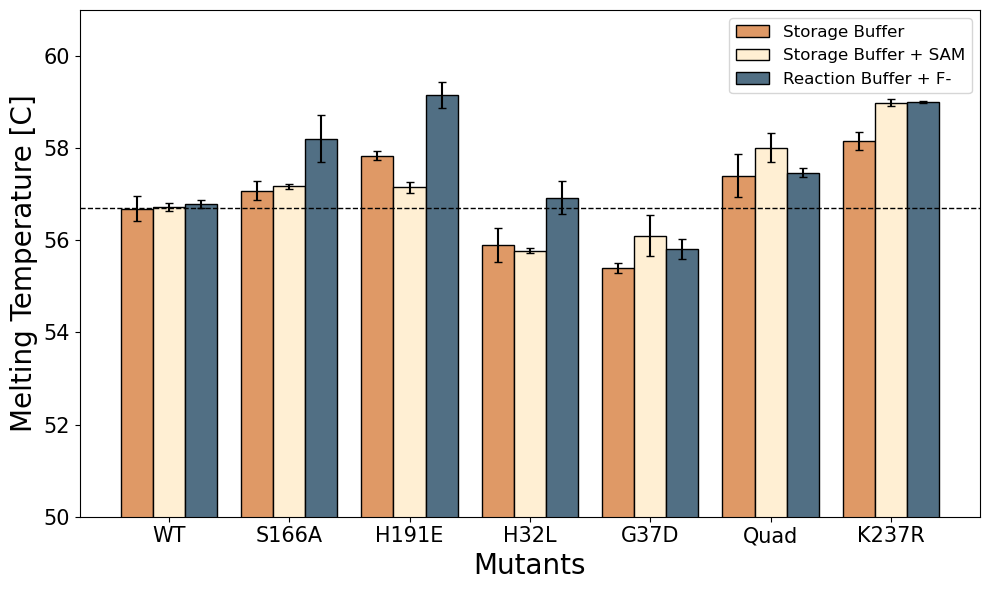

In [18]:
# Order proteins
protein_order = ["FlA_WT", "FlA_H191E", "FlA_H32L", "FlA_G37D", "FlA_S166A", "FlA_Quad", "FlA_K237R"]
plotdata["Protein"] = pd.Categorical(plotdata["Protein"], categories=protein_order, ordered=True)
plotdata = plotdata.sort_values(["Protein", "Ligand"])

# Order ligands
ligand_order = list(plotdata["Ligand"].drop_duplicates())

color_map = dict(zip(ligand_order, ["#DF9966", '#FFEFD3', "#516F84"][:len(ligand_order)]))

# Pivot for consistent alignment (rows: proteins, cols: ligands)
mean_piv = plotdata.pivot(index="Protein", columns="Ligand", values="mean").reindex(protein_order)
std_piv  = plotdata.pivot(index="Protein", columns="Ligand", values="std").reindex(protein_order)

# X positions and grouped bar offsets
x = np.arange(len(protein_order))
nL = len(ligand_order)
total_width = 0.8
bar_w = total_width / max(nL, 1)
offsets = (np.arange(nL) - (nL - 1) / 2.0) * bar_w

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, lig in enumerate(ligand_order):
    y    = mean_piv[lig].to_numpy()
    yerr = std_piv[lig].to_numpy()
    # Handle missing combos gracefully
    y_plot    = np.nan_to_num(y, nan=0.0)
    yerr_plot = np.nan_to_num(yerr, nan=0.0)

    ax.bar(
        x + offsets[i],
        y_plot,
        width=bar_w,
        yerr=yerr_plot,
        label=lig_dict.get(lig, lig),
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=color_map.get(lig, None),
    )

# Reference line and limits
ax.axhline(56.7, linestyle="--", linewidth=1.0, color="black")
ax.set_ylim(50, 60)

# Labels, ticks, legend
ax.set_xlabel("Mutants",fontsize=20)
ax.set_ylabel("Melting Temperature [C]",fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"], rotation=0, ha="center")
ax.legend(fontsize=12)

ax.set_ylim(50,61)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

